In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
DATA_DIR = Path(r"P:\HACKATHONS\SIH26PS67\DATA\REF")
COASTLINE_DIR = DATA_DIR / "coastline"
GSHHG_DIR = COASTLINE_DIR / "gshhg"   # notice the G at the end

GSHHS_DIR = GSHHG_DIR / "GSHHS_shp"   # notice the S at the end
WDBII_DIR = GSHHG_DIR / "WDBII_shp"

In [3]:
REPRESENTATIVE_RESOLUTION = "c"
REPRESENTATIVE_LEVEL = 1

representative_path = (
    GSHHS_DIR
    / REPRESENTATIVE_RESOLUTION
    / f"GSHHS_{REPRESENTATIVE_RESOLUTION}_L{REPRESENTATIVE_LEVEL}.shp"
)

representative_path

WindowsPath('P:/HACKATHONS/SIH26PS67/DATA/REF/coastline/gshhg/GSHHS_shp/c/GSHHS_c_L1.shp')

In [4]:
gdf = gpd.read_file(representative_path)

print(f"Features: {len(gdf):,}")
print(f"CRS: {gdf.crs}")
print(f"Geometry column: {gdf.geometry.name}")

Features: 742
CRS: EPSG:4326
Geometry column: geometry


In [5]:
geometry_type_counts = (
    gdf.geometry.geom_type
    .value_counts()
    .rename_axis("geometry_type")
    .reset_index(name="count")
)

geometry_type_counts

,geometry_type,count
0,Polygon,742


In [6]:
geometry_type_counts["percentage"] = (
    geometry_type_counts["count"]
    / geometry_type_counts["count"].sum()
    * 100
)

geometry_type_counts

,geometry_type,count,percentage
0,Polygon,742,100.0


In [7]:
empty_count = gdf.geometry.is_empty.sum()
null_count = gdf.geometry.isna().sum()

print(f"Empty geometries: {empty_count:,}")
print(f"Null geometries:  {null_count:,}")

Empty geometries: 0
Null geometries:  0


In [8]:
validity = gdf.geometry.is_valid

print(f"Valid geometries:   {validity.sum():,}")
print(f"Invalid geometries: {(~validity).sum():,}")

Valid geometries:   742
Invalid geometries: 0


In [9]:
def count_ring_vertices(ring):
    return len(ring.coords)


def count_polygon_vertices(polygon):
    count = count_ring_vertices(polygon.exterior)

    for interior in polygon.interiors:
        count += count_ring_vertices(interior)

    return count


def count_geometry_vertices(geometry):
    if geometry is None or geometry.is_empty:
        return 0

    geometry_type = geometry.geom_type

    if geometry_type == "Polygon":
        return count_polygon_vertices(geometry)

    if geometry_type == "MultiPolygon":
        return sum(
            count_polygon_vertices(polygon)
            for polygon in geometry.geoms
        )

    if hasattr(geometry, "geoms"):
        return sum(
            count_geometry_vertices(part)
            for part in geometry.geoms
        )

    if hasattr(geometry, "coords"):
        return len(geometry.coords)

    return 0

In [10]:
gdf["vertex_count"] = gdf.geometry.apply(count_geometry_vertices)

gdf["vertex_count"].describe()

count     742.000000
mean        9.814016
std        48.290679
min         4.000000
25%         4.000000
50%         4.000000
75%         5.000000
max      1004.000000
Name: vertex_count, dtype: float64

In [11]:
complexity_stats = gdf["vertex_count"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

complexity_stats

count     742.000000
mean        9.814016
std        48.290679
min         4.000000
50%         4.000000
75%         5.000000
90%         8.000000
95%        15.950000
99%        85.620000
max      1004.000000
Name: vertex_count, dtype: float64

In [12]:
total_vertices = gdf["vertex_count"].sum()

print(f"Total vertices: {total_vertices:,}")

Total vertices: 7,282


In [13]:
average_vertices = gdf["vertex_count"].mean()

print(f"Average vertices per feature: {average_vertices:,.2f}")

Average vertices per feature: 9.81


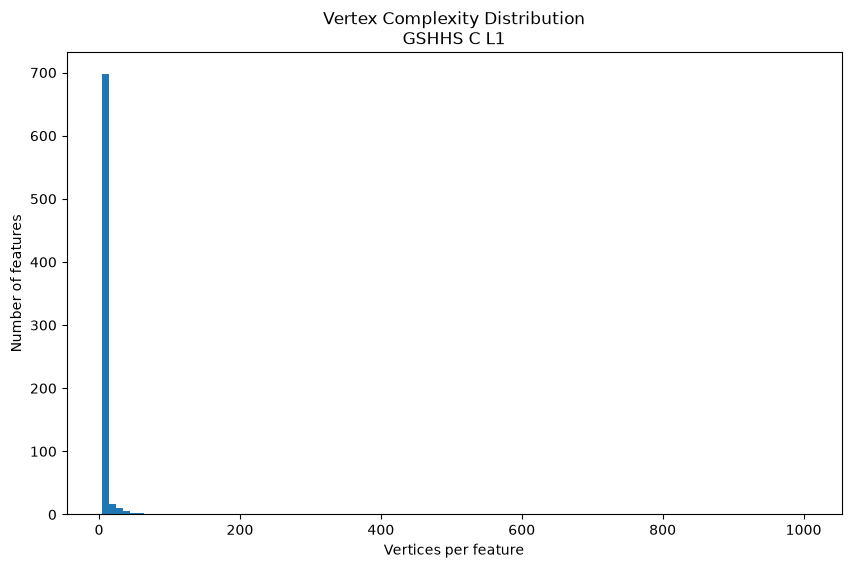

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    gdf["vertex_count"],
    bins=100,
)

plt.xlabel("Vertices per feature")
plt.ylabel("Number of features")
plt.title(
    f"Vertex Complexity Distribution\n"
    f"GSHHS {REPRESENTATIVE_RESOLUTION.upper()} L{REPRESENTATIVE_LEVEL}"
)

plt.show()

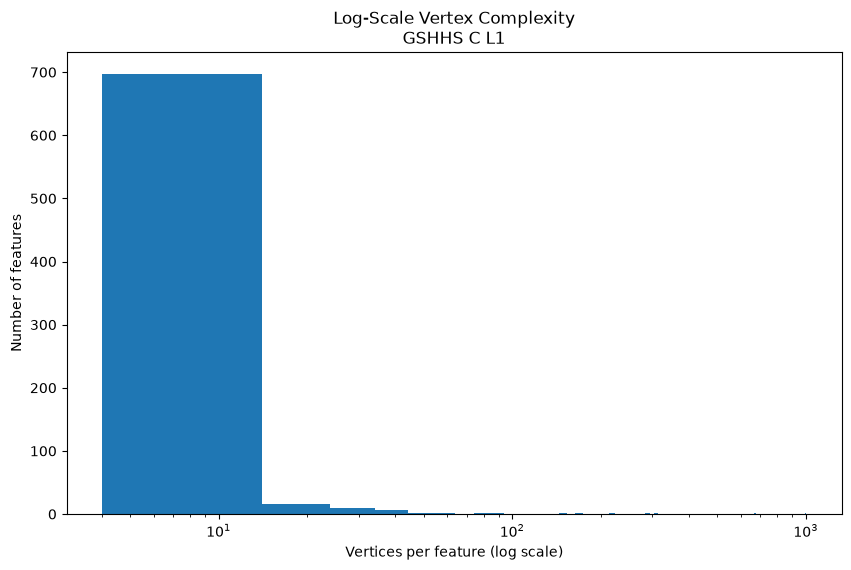

In [15]:
plt.figure(figsize=(10, 6))

plt.hist(
    gdf.loc[gdf["vertex_count"] > 0, "vertex_count"],
    bins=100,
)

plt.xscale("log")

plt.xlabel("Vertices per feature (log scale)")
plt.ylabel("Number of features")
plt.title(
    f"Log-Scale Vertex Complexity\n"
    f"GSHHS {REPRESENTATIVE_RESOLUTION.upper()} L{REPRESENTATIVE_LEVEL}"
)

plt.show()

In [16]:
available_columns = [
    column
    for column in [
        "vertex_count",
        "id",
        "level",
        "area",
        "area_full",
        "container",
        "ancestor",
        "geometry",
    ]
    if column in gdf.columns
]

top_complex_features = (
    gdf[available_columns]
    .sort_values("vertex_count", ascending=False)
    .head(20)
)

top_complex_features

,vertex_count,id,level,area,geometry
0,1004,0-E,1,5.065405e+07,"POLYGON ((180 68.99378, 180 65.08455, 179.5250..."
3,667,2,1,2.015474e+07,"POLYGON ((-81.08258 8.80839, -79.9095 9.35944,..."
4,311,3,1,1.753416e+07,"POLYGON ((-73.36172 -53.00042, -73.36261 -53, ..."
6,292,7,1,2.113828e+06,"POLYGON ((-44.69928 59.995, -44.46833 60.53872..."
2,221,1,1,2.922097e+07,"POLYGON ((31.91917 31.53122, 32.2845 31.23281,..."
5,170,6,1,7.592692e+06,"POLYGON ((146.23003 -38.69708, 146.27622 -39, ..."
10,152,11,1,4.806550e+05,"POLYGON ((-65.99914 61.95494, -65.99839 61.953..."
15,93,16,1,2.021983e+05,"POLYGON ((-77.08806 83.12564, -77 83.12947, -6..."
7,75,8,1,7.800249e+05,"POLYGON ((150 -10.08792, 150.00503 -10.08794, ..."
8,60,9,1,7.325867e+05,"POLYGON ((115 -4.01458, 114.99836 -4.01628, 11..."


In [17]:
complexity_ranked = gdf[
    ["vertex_count"]
].sort_values(
    "vertex_count",
    ascending=False
).reset_index(drop=True)

complexity_ranked["cumulative_vertices"] = (
    complexity_ranked["vertex_count"].cumsum()
)

complexity_ranked["cumulative_percentage"] = (
    complexity_ranked["cumulative_vertices"]
    / complexity_ranked["vertex_count"].sum()
    * 100
)

complexity_ranked.head(20)

,vertex_count,cumulative_vertices,cumulative_percentage
0,1004,1004,13.787421
1,667,1671,22.946993
2,311,1982,27.217797
3,292,2274,31.227685
4,221,2495,34.262565
5,170,2665,36.597089
6,152,2817,38.684427
7,93,2910,39.961549
8,75,2985,40.991486
9,60,3045,41.815435


In [18]:
for fraction in [0.001, 0.01, 0.05, 0.10, 0.25, 0.50]:
    n = max(1, int(len(complexity_ranked) * fraction))

    contribution = (
        complexity_ranked.head(n)["vertex_count"].sum()
        / complexity_ranked["vertex_count"].sum()
        * 100
    )

    print(
        f"Top {fraction * 100:>5.1f}% of features "
        f"contain {contribution:>6.2f}% of all vertices"
    )

Top   0.1% of features contain  13.79% of all vertices
Top   1.0% of features contain  38.68% of all vertices
Top   5.0% of features contain  52.86% of all vertices
Top  10.0% of features contain  58.47% of all vertices
Top  25.0% of features contain  67.87% of all vertices
Top  50.0% of features contain  79.62% of all vertices


In [19]:
def count_polygon_parts(geometry):
    if geometry is None or geometry.is_empty:
        return 0

    if geometry.geom_type == "Polygon":
        return 1

    if geometry.geom_type == "MultiPolygon":
        return len(geometry.geoms)

    if hasattr(geometry, "geoms"):
        return sum(
            count_polygon_parts(part)
            for part in geometry.geoms
        )

    return 0

In [20]:
gdf["polygon_parts"] = gdf.geometry.apply(count_polygon_parts)

gdf["polygon_parts"].describe()

count    742.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: polygon_parts, dtype: float64

In [21]:
(
    gdf[
        [
            "polygon_parts",
            "vertex_count",
            "id",
            "level",
            "geometry",
        ]
    ]
    .sort_values(
        ["polygon_parts", "vertex_count"],
        ascending=False,
    )
    .head(20)
)

,polygon_parts,vertex_count,id,level,geometry
0,1,1004,0-E,1,"POLYGON ((180 68.99378, 180 65.08455, 179.5250..."
3,1,667,2,1,"POLYGON ((-81.08258 8.80839, -79.9095 9.35944,..."
4,1,311,3,1,"POLYGON ((-73.36172 -53.00042, -73.36261 -53, ..."
6,1,292,7,1,"POLYGON ((-44.69928 59.995, -44.46833 60.53872..."
2,1,221,1,1,"POLYGON ((31.91917 31.53122, 32.2845 31.23281,..."
5,1,170,6,1,"POLYGON ((146.23003 -38.69708, 146.27622 -39, ..."
10,1,152,11,1,"POLYGON ((-65.99914 61.95494, -65.99839 61.953..."
15,1,93,16,1,"POLYGON ((-77.08806 83.12564, -77 83.12947, -6..."
7,1,75,8,1,"POLYGON ((150 -10.08792, 150.00503 -10.08794, ..."
8,1,60,9,1,"POLYGON ((115 -4.01458, 114.99836 -4.01628, 11..."


In [22]:
def count_polygon_holes(polygon):
    return len(polygon.interiors)


def count_geometry_holes(geometry):
    if geometry is None or geometry.is_empty:
        return 0

    if geometry.geom_type == "Polygon":
        return count_polygon_holes(geometry)

    if geometry.geom_type == "MultiPolygon":
        return sum(
            count_polygon_holes(polygon)
            for polygon in geometry.geoms
        )

    if hasattr(geometry, "geoms"):
        return sum(
            count_geometry_holes(part)
            for part in geometry.geoms
        )

    return 0

In [23]:
gdf["hole_count"] = gdf.geometry.apply(count_geometry_holes)

gdf["hole_count"].describe()

count    742.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: hole_count, dtype: float64

In [24]:
complexity_columns = [
    "vertex_count",
    "polygon_parts",
    "hole_count",
]

complexity_summary = gdf[complexity_columns].describe().T

complexity_summary

,count,mean,std,min,25%,50%,75%,max
vertex_count,742.0,9.814016,48.290679,4.0,4.0,4.0,5.0,1004.0
polygon_parts,742.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
hole_count,742.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [25]:
bounds = gdf.geometry.bounds

gdf["minx"] = bounds["minx"]
gdf["miny"] = bounds["miny"]
gdf["maxx"] = bounds["maxx"]
gdf["maxy"] = bounds["maxy"]

gdf["bbox_width_deg"] = gdf["maxx"] - gdf["minx"]
gdf["bbox_height_deg"] = gdf["maxy"] - gdf["miny"]

In [26]:
gdf[
    [
        "bbox_width_deg",
        "bbox_height_deg",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
bbox_width_deg,742.0,1.916641,9.304898,0.001667,0.249166,0.449694,1.040021,189.500389
bbox_height_deg,742.0,1.102962,5.420186,0.002500,0.164368,0.292597,0.592216,76.446750


In [27]:
gdf["wkb_size"] = gdf.geometry.to_wkb().str.len()

gdf["wkb_size"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count      742.000000
mean       170.024259
std        772.650860
min         77.000000
50%         77.000000
75%         93.000000
90%        141.000000
95%        268.200000
99%       1382.920000
max      16077.000000
Name: wkb_size, dtype: float64

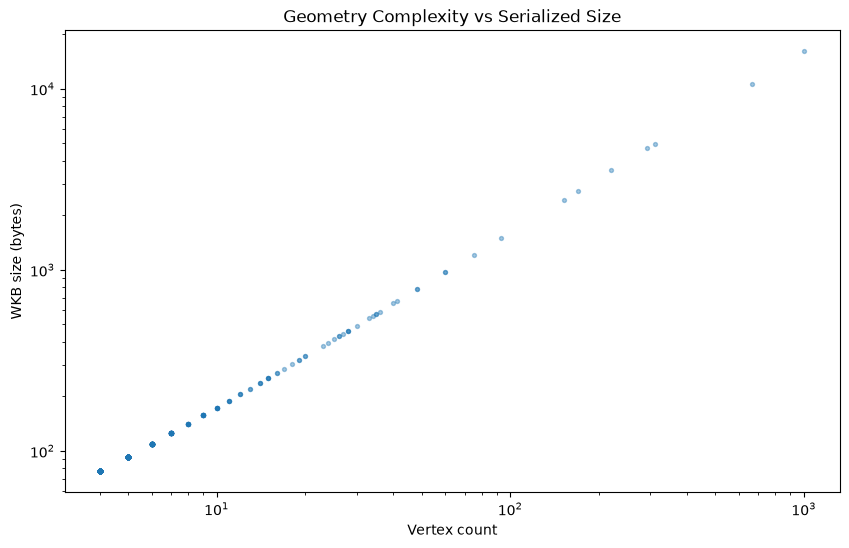

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    gdf["vertex_count"],
    gdf["wkb_size"],
    s=8,
    alpha=0.4,
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Vertex count")
plt.ylabel("WKB size (bytes)")
plt.title("Geometry Complexity vs Serialized Size")

plt.show()

In [29]:
gdf["geometry_type"] = gdf.geometry.geom_type
geometry_complexity = (
    gdf.groupby("geometry_type", observed=True)
)

In [30]:
geometry_complexity = (
    gdf.groupby("geometry_type")["vertex_count"]
    .agg(
        features="count",
        total_vertices="sum",
        mean_vertices="mean",
        median_vertices="median",
        max_vertices="max",
    )
)

geometry_complexity

,features,total_vertices,mean_vertices,median_vertices,max_vertices
geometry_type,,,,,
Polygon,742,7282,9.814016,4.0,1004


In [31]:
def analyze_resolution(resolution, level=1):
    path = (
        GSHHS_DIR
        / resolution
        / f"GSHHS_{resolution}_L{level}.shp"
    )

    data = gpd.read_file(path)

    data["vertex_count"] = data.geometry.apply(
        count_geometry_vertices
    )

    data["polygon_parts"] = data.geometry.apply(
        count_polygon_parts
    )

    data["hole_count"] = data.geometry.apply(
        count_geometry_holes
    )

    data["wkb_size"] = data.geometry.to_wkb().str.len()

    return {
        "resolution": resolution,
        "features": len(data),
        "total_vertices": data["vertex_count"].sum(),
        "mean_vertices": data["vertex_count"].mean(),
        "median_vertices": data["vertex_count"].median(),
        "p95_vertices": data["vertex_count"].quantile(0.95),
        "p99_vertices": data["vertex_count"].quantile(0.99),
        "max_vertices": data["vertex_count"].max(),
        "total_wkb_bytes": data["wkb_size"].sum(),
        "total_polygon_parts": data["polygon_parts"].sum(),
        "total_holes": data["hole_count"].sum(),
    }

In [32]:
resolution_results = []

RESOLUTIONS = ["c", "l", "i", "h", "f"]

for resolution in RESOLUTIONS:
    print(f"Processing {resolution}...")

    result = analyze_resolution(
        resolution=resolution,
        level=1,
    )

    resolution_results.append(result)

resolution_complexity = pd.DataFrame(resolution_results)

resolution_complexity

Processing c...
Processing l...
Processing i...
Processing h...
Processing f...


,resolution,features,total_vertices,mean_vertices,median_vertices,p95_vertices,p99_vertices,max_vertices,total_wkb_bytes,total_polygon_parts,total_holes
0,c,742,7282,9.814016,4.0,15.95,85.62,1004,126158,742,0
1,l,5706,56351,9.875745,4.0,12.00,55.00,6733,975794,5706,0
2,i,32830,340359,10.367316,4.0,13.00,47.00,34332,5872534,32830,0
3,h,144749,1626467,11.236465,4.0,14.00,56.00,139786,27905209,144749,0
4,f,179837,9453089,52.564761,10.0,69.00,324.00,1160926,153587305,179837,0


In [33]:
RESOLUTION_INFO = {
    "f": {
        "name": "Full",
        "description": "Maximum resolution; original data has not been decimated."
    },
    "h": {
        "name": "High",
        "description": "Reduced from full resolution using Douglas-Peucker simplification."
    },
    "i": {
        "name": "Intermediate",
        "description": "Reduced from high resolution using Douglas-Peucker simplification."
    },
    "l": {
        "name": "Low",
        "description": "Reduced from intermediate resolution using Douglas-Peucker simplification."
    },
    "c": {
        "name": "Crude",
        "description": "Reduced from low resolution using Douglas-Peucker simplification."
    },
}

LEVEL_INFO = {
    1: {
        "name": "Land",
        "description": "Continental land masses and ocean islands, except Antarctica."
    },
    2: {
        "name": "Lake",
        "description": "Lakes."
    },
    3: {
        "name": "Island in lake",
        "description": "Islands contained within lakes."
    },
    4: {
        "name": "Pond in island in lake",
        "description": "Ponds contained within islands inside lakes."
    },
    5: {
        "name": "Antarctica Ice",
        "description": "Boundaries of Antarctica Ice and Ocean."
    },
    6: {
        "name": "Antarctica Grounds",
        "description": "Boundaries of Antarctica Grounds and Ocean."
    }
}

In [34]:
resolution_complexity["resolution_name"] = (
    resolution_complexity["resolution"]
    .map({
        code: info["name"]
        for code, info in RESOLUTION_INFO.items()
    })
)

resolution_complexity

,resolution,features,total_vertices,mean_vertices,median_vertices,p95_vertices,p99_vertices,max_vertices,total_wkb_bytes,total_polygon_parts,total_holes,resolution_name
0,c,742,7282,9.814016,4.0,15.95,85.62,1004,126158,742,0,Crude
1,l,5706,56351,9.875745,4.0,12.00,55.00,6733,975794,5706,0,Low
2,i,32830,340359,10.367316,4.0,13.00,47.00,34332,5872534,32830,0,Intermediate
3,h,144749,1626467,11.236465,4.0,14.00,56.00,139786,27905209,144749,0,High
4,f,179837,9453089,52.564761,10.0,69.00,324.00,1160926,153587305,179837,0,Full


In [35]:
full_vertices = resolution_complexity.loc[
    resolution_complexity["resolution"] == "f",
    "total_vertices"
].iloc[0]

resolution_complexity["vertex_reduction_vs_full_pct"] = (
    1
    - resolution_complexity["total_vertices"]
    / full_vertices
) * 100

resolution_complexity[
    [
        "resolution",
        "resolution_name",
        "total_vertices",
        "vertex_reduction_vs_full_pct",
    ]
]

,resolution,resolution_name,total_vertices,vertex_reduction_vs_full_pct
0,c,Crude,7282,99.922967
1,l,Low,56351,99.403888
2,i,Intermediate,340359,96.399494
3,h,High,1626467,82.794333
4,f,Full,9453089,0.000000


In [36]:
full_wkb = resolution_complexity.loc[
    resolution_complexity["resolution"] == "f",
    "total_wkb_bytes"
].iloc[0]

resolution_complexity["wkb_reduction_vs_full_pct"] = (
    1
    - resolution_complexity["total_wkb_bytes"]
    / full_wkb
) * 100

resolution_complexity[
    [
        "resolution",
        "resolution_name",
        "total_wkb_bytes",
        "wkb_reduction_vs_full_pct",
    ]
]

,resolution,resolution_name,total_wkb_bytes,wkb_reduction_vs_full_pct
0,c,Crude,126158,99.917859
1,l,Low,975794,99.364665
2,i,Intermediate,5872534,96.176420
3,h,High,27905209,81.831045
4,f,Full,153587305,0.000000


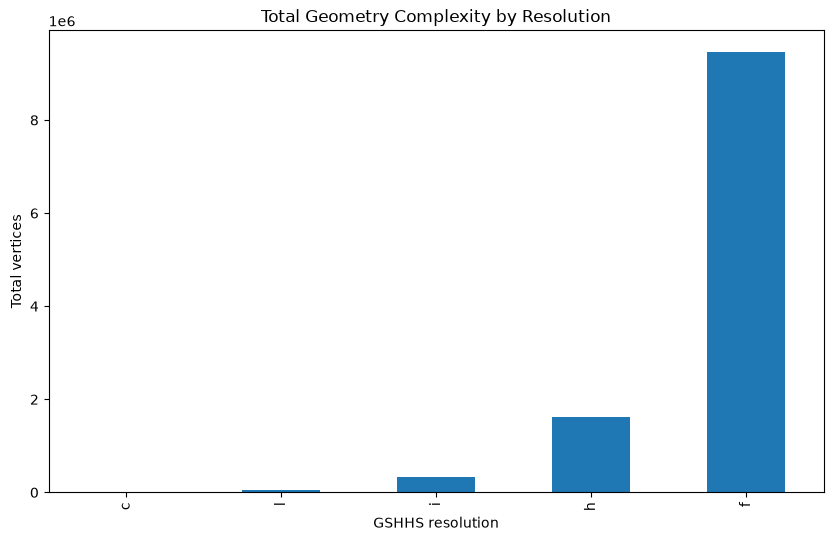

In [37]:
plot_data = (
    resolution_complexity
    .set_index("resolution")["total_vertices"]
    .reindex(RESOLUTIONS)
)

plt.figure(figsize=(10, 6))

plot_data.plot(kind="bar")

plt.xlabel("GSHHS resolution")
plt.ylabel("Total vertices")
plt.title("Total Geometry Complexity by Resolution")

plt.show()

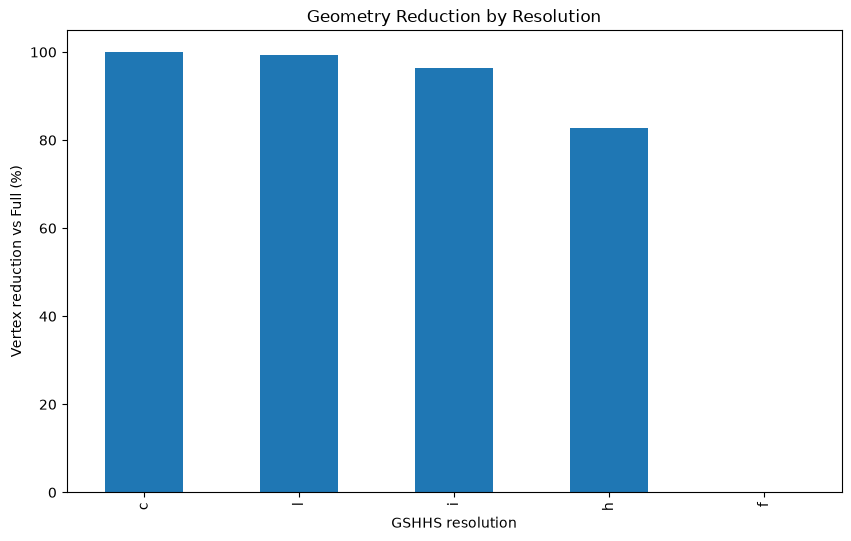

In [38]:
plot_data = (
    resolution_complexity
    .set_index("resolution")[
        "vertex_reduction_vs_full_pct"
    ]
    .reindex(RESOLUTIONS)
)

plt.figure(figsize=(10, 6))

plot_data.plot(kind="bar")

plt.xlabel("GSHHS resolution")
plt.ylabel("Vertex reduction vs Full (%)")
plt.title("Geometry Reduction by Resolution")

plt.show()

In [39]:
comparison = resolution_complexity[
    [
        "resolution",
        "features",
        "total_vertices",
        "mean_vertices",
        "median_vertices",
        "p95_vertices",
        "p99_vertices",
    ]
].copy()

comparison

,resolution,features,total_vertices,mean_vertices,median_vertices,p95_vertices,p99_vertices
0,c,742,7282,9.814016,4.0,15.95,85.62
1,l,5706,56351,9.875745,4.0,12.00,55.00
2,i,32830,340359,10.367316,4.0,13.00,47.00
3,h,144749,1626467,11.236465,4.0,14.00,56.00
4,f,179837,9453089,52.564761,10.0,69.00,324.00


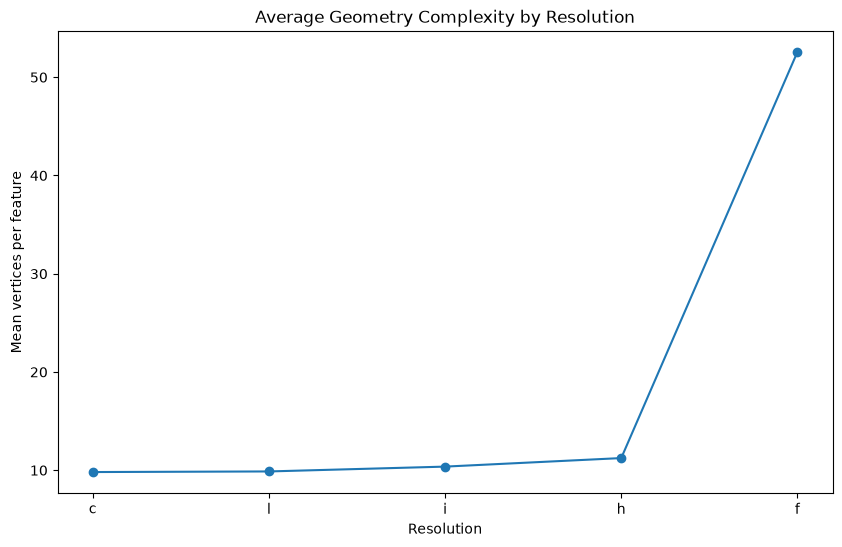

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    resolution_complexity["resolution"],
    resolution_complexity["mean_vertices"],
    marker="o",
)

plt.xlabel("Resolution")
plt.ylabel("Mean vertices per feature")
plt.title("Average Geometry Complexity by Resolution")

plt.show()

In [41]:
pathological_features = []

for resolution in RESOLUTIONS:
    path = (
        GSHHS_DIR
        / resolution
        / "GSHHS_{}_L1.shp".format(resolution)
    )

    data = gpd.read_file(path)

    data["vertex_count"] = data.geometry.apply(
        count_geometry_vertices
    )

    top = (
        data[
            [
                "vertex_count",
                "id",
                "level",
                "area",
                "geometry",
            ]
        ]
        .sort_values("vertex_count", ascending=False)
        .head(10)
        .copy()
    )

    top["resolution"] = resolution

    pathological_features.append(top)

pathological_features = pd.concat(
    pathological_features,
    ignore_index=True,
)

pathological_features

,vertex_count,id,level,area,geometry,resolution
0,1004,0-E,1,5.065405e+07,"POLYGON ((180 68.99378, 180 65.08455, 179.5250...",c
1,667,2,1,2.015474e+07,"POLYGON ((-81.08258 8.80839, -79.9095 9.35944,...",c
2,311,3,1,1.753416e+07,"POLYGON ((-73.36172 -53.00042, -73.36261 -53, ...",c
3,292,7,1,2.113828e+06,"POLYGON ((-44.69928 59.995, -44.46833 60.53872...",c
4,221,1,1,2.922097e+07,"POLYGON ((31.91917 31.53122, 32.2845 31.23281,...",c
5,170,6,1,7.592692e+06,"POLYGON ((146.23003 -38.69708, 146.27622 -39, ...",c
6,152,11,1,4.806550e+05,"POLYGON ((-65.99914 61.95494, -65.99839 61.953...",c
7,93,16,1,2.021983e+05,"POLYGON ((-77.08806 83.12564, -77 83.12947, -6...",c
8,75,8,1,7.800249e+05,"POLYGON ((150 -10.08792, 150.00503 -10.08794, ...",c
9,60,9,1,7.325867e+05,"POLYGON ((115 -4.01458, 114.99836 -4.01628, 11...",c


In [42]:
geometry_complexity_report = resolution_complexity[
    [
        "resolution",
        "resolution_name",
        "features",
        "total_vertices",
        "mean_vertices",
        "median_vertices",
        "p95_vertices",
        "p99_vertices",
        "max_vertices",
        "total_polygon_parts",
        "total_holes",
        "total_wkb_bytes",
        "vertex_reduction_vs_full_pct",
        "wkb_reduction_vs_full_pct",
    ]
].copy()

geometry_complexity_report

,resolution,resolution_name,features,total_vertices,mean_vertices,median_vertices,p95_vertices,p99_vertices,max_vertices,total_polygon_parts,total_holes,total_wkb_bytes,vertex_reduction_vs_full_pct,wkb_reduction_vs_full_pct
0,c,Crude,742,7282,9.814016,4.0,15.95,85.62,1004,742,0,126158,99.922967,99.917859
1,l,Low,5706,56351,9.875745,4.0,12.00,55.00,6733,5706,0,975794,99.403888,99.364665
2,i,Intermediate,32830,340359,10.367316,4.0,13.00,47.00,34332,32830,0,5872534,96.399494,96.176420
3,h,High,144749,1626467,11.236465,4.0,14.00,56.00,139786,144749,0,27905209,82.794333,81.831045
4,f,Full,179837,9453089,52.564761,10.0,69.00,324.00,1160926,179837,0,153587305,0.000000,0.000000
